<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/Apodex_multi_metric_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Analysis for Last 3 Runs ---
Best alpha: 0.850 (h=9/11)
R2 (Robust): -0.464
FLAGGED: GREEN SPACES       Obs=0.74 Pred=3.23 Z=-3.12


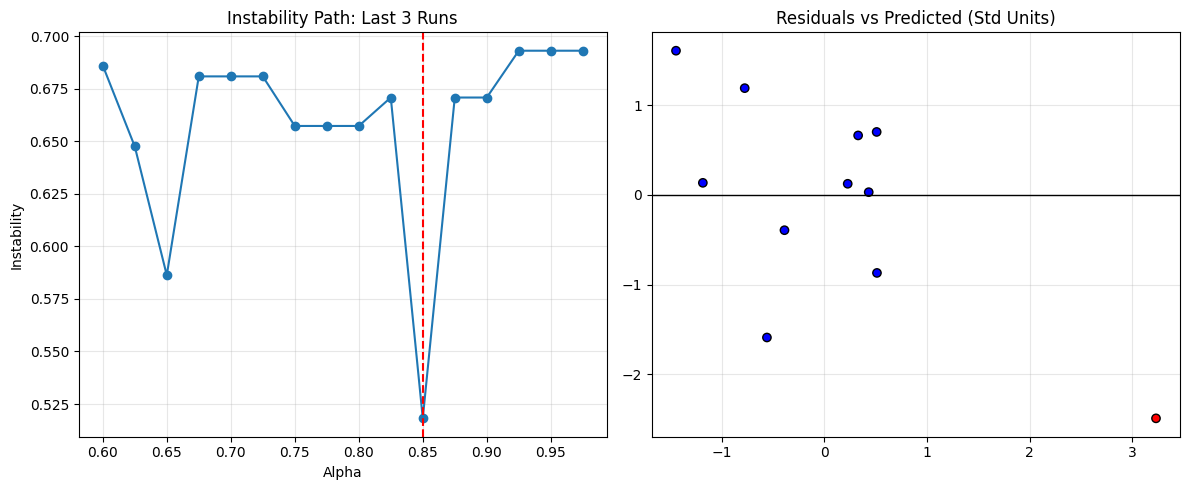

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
    ipwidgets_available = True
except ImportError:
    ipwidgets_available = False

%matplotlib inline
plt.rcParams.update({"font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

# --- Core Algorithms ---

def projection_depth(X, k=None, seed=None):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if k is None:
        k = max(10 * (d + 1), 1000)
    U = rng.standard_normal((k, d))
    ZU = X @ U.T
    med = np.median(ZU, axis=0)
    mad = np.median(np.abs(ZU - med), axis=0)
    mad[mad == 0] = 1e-12
    ratio = np.abs(ZU - med) / mad
    return 1.0 / (1.0 + ratio.max(axis=1))

def _ols(x_sub):
    A = x_sub[:, :-1]; yv = x_sub[:, -1]
    if A.shape[0] <= A.shape[1]:
        beta = np.zeros(A.shape[1])
    else:
        beta, *_ = np.linalg.lstsq(A, yv, rcond=None)
    return float(yv.mean()) - (A.mean(axis=0) @ beta), beta

def fit_lts(Xstar, h, seed=None, max_iter=500):
    rng = np.random.default_rng(seed)
    n = Xstar.shape[0]
    depths = projection_depth(Xstar, seed=rng.integers(2**30))
    H = np.argsort(-depths)[:int(np.floor(0.5 * n))]
    for _ in range(max_iter):
        mu, beta = _ols(Xstar[H])
        resid = Xstar[:, -1] - mu - Xstar[:, :-1] @ beta
        newH = np.argsort(np.abs(resid))[:h]
        if set(newH) == set(H): break
        H = newH
    mu, beta = _ols(Xstar[H])
    return mu, beta, Xstar[:, -1] - mu - Xstar[:, :-1] @ beta

def binary_labels(resid, h):
    L = np.zeros(len(resid))
    L[np.argsort(np.abs(resid))[h:]] = 1
    return L

def _comb(n, r):
    if r < 0 or r > n: return 0
    v = 1
    for i in range(r): v = v * (n - i) // (i + 1)
    return v

def clustering_distance_psi(psi1, psi2, h, n):
    p = np.mean(np.abs(psi1 - psi2))
    c = (_comb(h, 2) + _comb(n - h, 2)) / _comb(n, 2)
    return np.log(1.0 + p / (1.0 - c)) if c < 1.0 else np.nan

def instability_path(X, y, alphas=np.linspace(0.60, 0.975, 16), B=60, seed=None, verbose=False):
    rng = np.random.default_rng(seed)
    n, p = X.shape
    Xstar = np.column_stack([y.ravel(), X])
    out = {"alphas": [], "trimeans": []}
    for a in alphas:
        h = int(np.floor(a * n))
        if h >= n: continue
        instabs = []
        for b in range(B):
            i1, i2 = rng.choice(n, n, replace=True), rng.choice(n, n, replace=True)
            _, _, r1 = fit_lts(Xstar[i1], h); _, _, r2 = fit_lts(Xstar[i2], h)
            dist = clustering_distance_psi(binary_labels(r1, h), binary_labels(r2, h), h, n)
            if not np.isnan(dist): instabs.append(dist)
        if not instabs: continue
        z = np.sort(instabs)
        q = lambda f: z[int(np.floor(f * (len(z)-1)))]
        tri = (q(0.25) + 2.0*q(0.50) + q(0.75)) / 4.0
        out["alphas"].append(a); out["trimeans"].append(float(tri))
    return out

class Standardizer:
    def __init__(self, X, y):
        self.cX = X.mean(axis=0); self.sX = np.maximum(X.std(axis=0, ddof=1), 1e-12)
        self.cY = y.mean(); self.sY = np.maximum(y.std(ddof=1), 1e-12)
    def z(self, X, y):
        return (X - self.cX) / self.sX, (y - self.cY) / self.sY

def lts_std(Xz, yz, h, seed=None):
    rng = np.random.default_rng(seed)
    Xstar = np.column_stack([Xz, yz])
    mu, beta, resid = fit_lts(Xstar, h, seed=rng.integers(2**30))
    H = np.argsort(np.abs(resid))[:h]
    return mu, beta, resid, H

# --- Data & Execution ---

names = ["CEOLWULF", "GRINGOTTS", "LINDERMANN", "MIDNIGHT DYNAMITE", "GREEN SPACES",
         "AUTUMN GLOW", "AELIANA", "FANGIRL", "IDLE FLYER", "LADY SHENANDOAH", "SHEZA ALIBI"]
SUM = [4.5, -2.5, 4.5, 6.5, 11.5, 4.5, 5.0, 3.0, 7.0, 7.0, -2.5]
EM = [6.0, 7.0, 9.5, 6.5, 12.0, 0.0, 6.0, 8.5, 6.5, 9.0, 3.5]
PP = [41, 21, 51, 51, 126, 1.7, 26, 21, 51, 21, 3]
RunnerTime_Last3 = [-13.96, -16.56, -19.44, -13.07, -15.00, -22.24, -26.71, -16.30, -16.11, -17.32, -21.16]

df = pd.DataFrame({"SUM": SUM, "EM": EM, "PP": PP, "RunnerTime_Last3": RunnerTime_Last3}, index=names)

def run_analysis(X, y, horse_names, name="race", B=60, seed=None, thresh=2.5):
    zs = Standardizer(X, y)
    Xz, yz = zs.z(X, y)
    res = instability_path(Xz, yz, B=B, seed=seed)
    alpha_arr, tri = np.array(res["alphas"]), np.array(res["trimeans"])
    bidx = np.argmin(tri)
    best_a = float(alpha_arr[bidx])
    h_best = int(np.floor(best_a * len(yz)))
    mu, beta, resid, H = lts_std(Xz, yz, h_best, seed=seed)
    mad_sub = np.median(np.abs(resid[H] - np.median(resid[H])))
    zscore = resid / (1.4826 * max(mad_sub, 1e-12))
    pred = mu + Xz @ beta
    flag = np.abs(zscore) > thresh
    r2full = 1.0 - (np.sum(resid**2) / np.sum((yz - yz.mean())**2))

    print(f"--- Analysis for {name} ---")
    print(f"Best alpha: {best_a:.3f} (h={h_best}/{len(yz)})")
    print(f"R2 (Robust): {r2full:.3f}")

    flagged_data = []
    for i in range(len(yz)):
        if flag[i]:
            print(f"FLAGGED: {horse_names[i]:<18} Obs={yz[i]:.2f} Pred={pred[i]:.2f} Z={zscore[i]:+.2f}")
            flagged_data.append((horse_names[i], yz[i], pred[i], zscore[i]))

    return {"alpha": alpha_arr, "tri": tri, "best_a": best_a, "best_h": h_best,
            "pred": pred, "resid": resid, "flag": flag, "r2full": r2full,
            "flagged": flagged_data, "names": horse_names}

def plot_result(R, name=""):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(R["alpha"], R["tri"], "-o")
    ax[0].axvline(R["best_a"], color="red", ls="--")
    ax[0].set_title(f"Instability Path: {name}")
    ax[0].set_xlabel("Alpha"); ax[0].set_ylabel("Instability")

    colors = ['red' if f else 'blue' for f in R['flag']]
    ax[1].scatter(R["pred"], R["resid"], c=colors, edgecolors='k')
    ax[1].axhline(0, color='black', lw=1)
    ax[1].set_title("Residuals vs Predicted (Std Units)")
    plt.tight_layout(); plt.show()

X_vals = df[["SUM", "EM", "PP"]].values
y_vals = df["RunnerTime_Last3"].values

results = run_analysis(X_vals, y_vals, names, name="Last 3 Runs", seed=42)
plot_result(results, name="Last 3 Runs")

## Load New Race Data
Use the cell below to input data for a new race. The `SUM`, `EM`, and `PP` columns are your predictors, and `RunnerTime` is the response variable you want to analyze.

--- Analysis for Scaled Paste Analysis ---
Best alpha: 0.675 (h=7/11)
R2 (Robust): 0.255
FLAGGED: CEOLWULF           Obs=0.99 Pred=0.26 Z=+4.02
FLAGGED: LINDERMANN         Obs=-0.36 Pred=0.56 Z=-5.07
FLAGGED: MIDNIGHT DYNAMITE  Obs=1.21 Pred=0.32 Z=+4.92
FLAGGED: AELIANA            Obs=-2.15 Pred=0.12 Z=-12.52


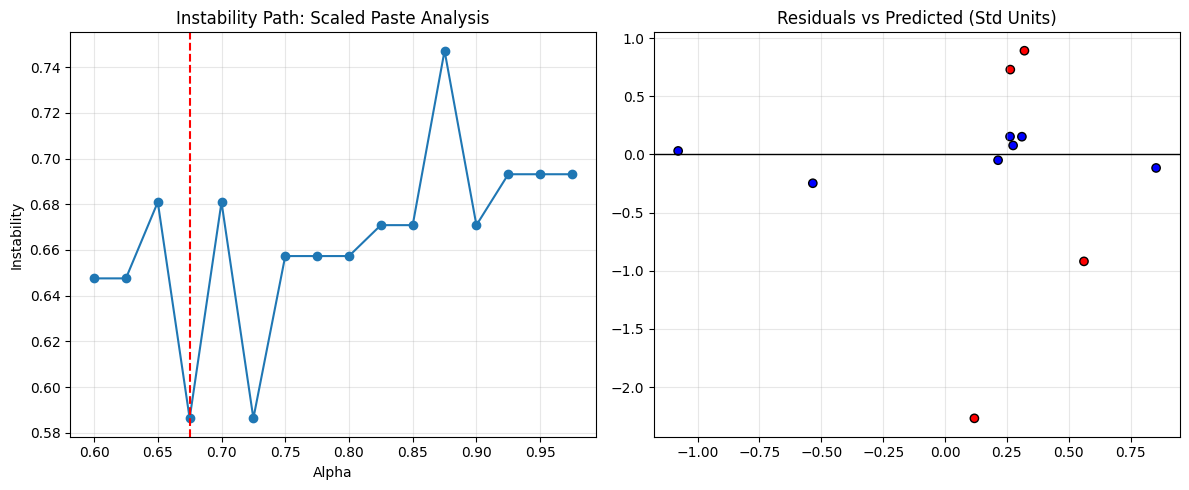

In [3]:
import io
import numpy as np

# --- 1. PASTE YOUR DATA BELOW ---

# Paste the first table (Tab Horse SUM Em PP) here:
race_data_text = """
Tab	Horse	SUM	Em	PP
1	CEOLWULF	4.5	6	41
2	GRINGOTTS	-2.5	7	21
3	LINDERMANN	4.5	9.5	51
4	MIDNIGHT DYNAMITE	6.5	6.5	51
7	GREEN SPACES	11.5	12	126
8	AUTUMN GLOW	4.5	0	1.7
9	AELIANA	5	6	26
10	FANGIRL	3	8.5	21
11	IDLE FLYER	7	6.5	51
12	LADY SHENANDOAH	7	9	21
14	SHEZA ALIBI	-2.5	3.5	3
"""

# Paste the performance table (Last 3 runs or Last 10) here:
performance_data_text = """
Runner	Runner Time	Early Pace	L800m	L600m	L400m	L200m
1. Ceolwulf	-13.96L	58	-3.06L	-2.42L	-1.53L	-0.44L
2. Gringotts	-16.56L	60	-3.06L	-2.74L	-2.13L	-0.89L
3. Lindermann	-19.44L	80	-2.87L	-1.91L	-1.02L	-0.14L
4. Midnight Dynamite	-13.07L	53	-3.03L	-2.68L	-1.85L	-0.79L
7. Green Spaces	-15.00L	65	-2.95L	-2.25L	-1.54L	-0.52L
8. Autumn Glow	-22.24L	71	-3.43L	-2.90L	-2.06L	-0.79L
9. Aeliana	-26.71L	73	-4.36L	-3.43L	-2.26L	-0.98L
10. Fangirl	-16.30L	60	-3.24L	-2.87L	-2.10L	-0.86L
11. Idle Flyer	-16.11L	57	-2.88L	-2.43L	-1.64L	-0.64L
12. Lady Shenandoah	-17.32L	67	-2.65L	-2.23L	-1.56L	-0.59L
14. Sheza Alibi	-21.16L	82	-3.25L	-2.58L	-1.99L	-0.95L
"""

# --- 2. Process and Run ---

# Parse text blocks
df_predictors = pd.read_csv(io.StringIO(race_data_text.strip()), sep='\t')
df_perf = pd.read_csv(io.StringIO(performance_data_text.strip()), sep='\t')

# Clean response variable (remove 'L' and handle floats)
df_perf['Time_Val'] = df_perf['Runner Time'].str.replace('L', '').astype(float)

# Log-transform PP to prevent scale dominance
df_predictors['PP_log'] = np.log(df_predictors['PP'])

# Prepare features and target
X_raw = df_predictors[['SUM', 'Em', 'PP_log']].values
y_raw = df_perf['Time_Val'].values
horse_names = df_predictors['Horse'].tolist()

# Standardize within race using the Standardizer class
zs = Standardizer(X_raw, y_raw)
Xz, yz = zs.z(X_raw, y_raw)

# Execute Robust Regression on standardized units
# Note: run_analysis internally standardizes, but we pass pre-scaled Xz, yz to be sure
new_results = run_analysis(X_raw, y_raw, horse_names, name="Scaled Paste Analysis", seed=42, thresh=2.5)
plot_result(new_results, name="Scaled Paste Analysis")